In [1]:
%env HF_HOME=data/cache
%env TORCH_HOME=data/cache
%cd ../
%pwd

env: HF_HOME=data/cache
env: TORCH_HOME=data/cache
/home/songlin/workspace/projects/SIMPLE


/home/songlin/workspace/projects/SIMPLE/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


'/home/songlin/workspace/projects/SIMPLE'

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
from lerobot.datasets.lerobot_dataset import LeRobotDataset

In [3]:
env_id = "simple/FrankaTabletopGrasp-v0"
data_dir = "data/datagen.test/simple/FrankaTabletopGrasp-v0/level-0"

In [5]:
# Load dataset
dataset = LeRobotDataset(repo_id=env_id,root=data_dir)
dataset.meta

LeRobotDatasetMetadata({
    Repository ID: 'simple/FrankaTabletopGrasp-v0',
    Total episodes: '1',
    Total frames: '108',
    Features: '['observation.rgb_front_stereo_left', 'observation.rgb_front_stereo_right', 'observation.rgb_wrist', 'observation.rgb_wrist_left', 'observation.rgb_side_left', 'observation.mujoco', 'observation.proprio_eef_pose', 'observation.proprio_joint_positions', 'action.gripper_state', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']',
})',

In [ ]:
eps_id = 0

In [8]:
from_idx = int(dataset.episode_data_index["from"][eps_id].item())
to_idx = int(dataset.episode_data_index["to"][eps_id].item())

Plot joint angles

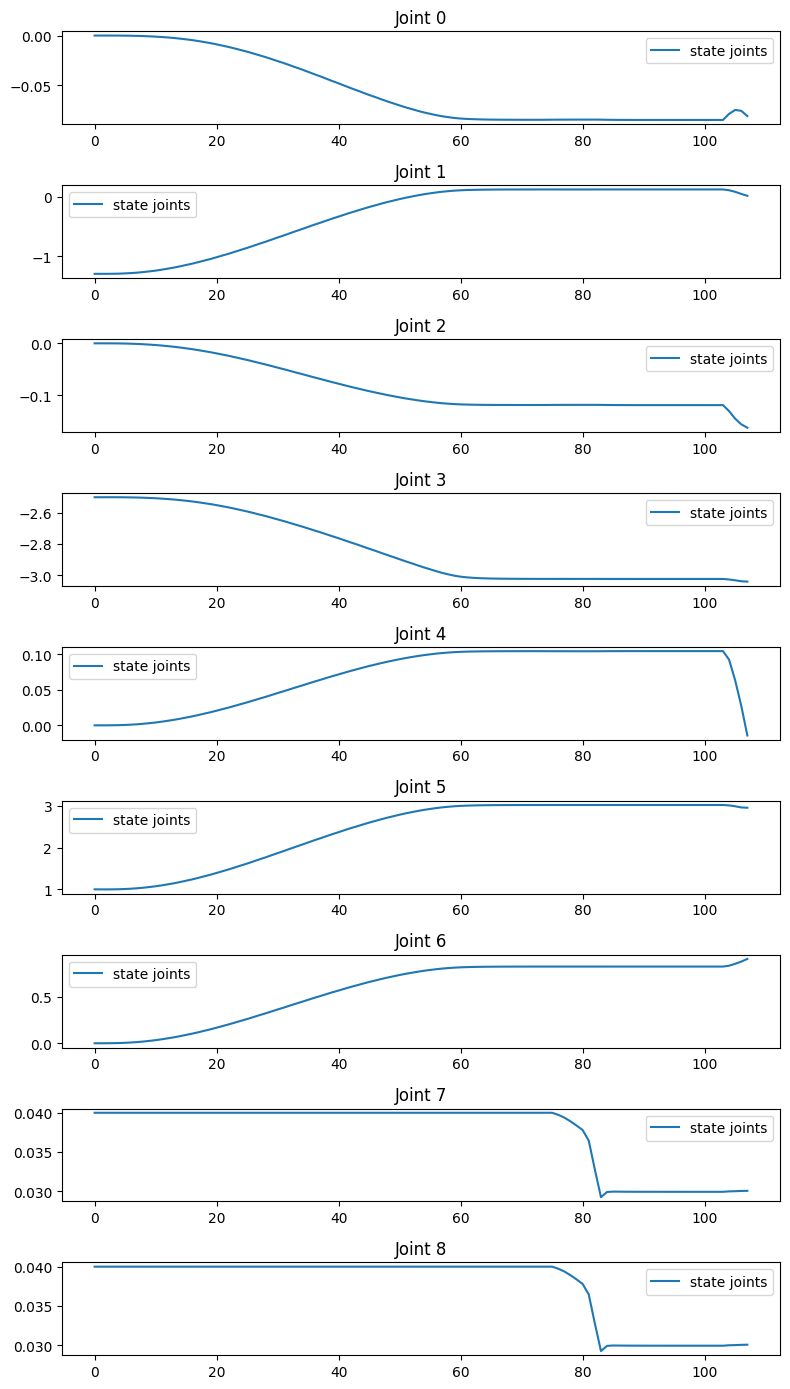

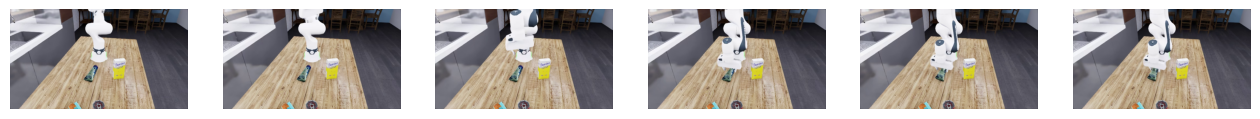

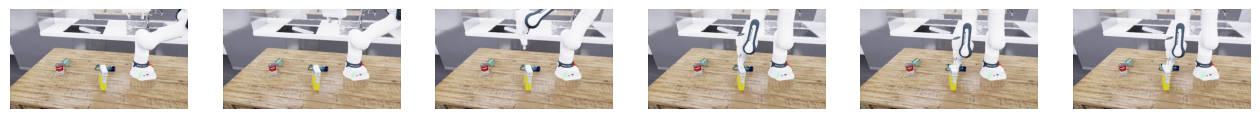

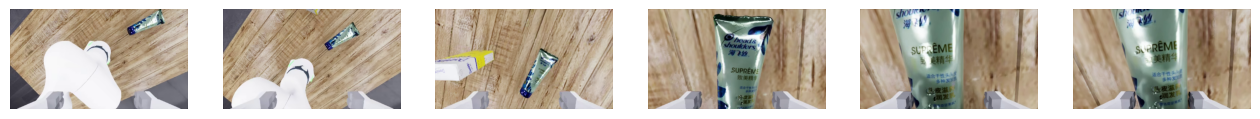

In [33]:
max_steps = to_idx - from_idx

state_joints_across_time = []
gt_action_joints_across_time = []
left_images = []
side_images = []
wrist_images = []

sample_images = 6

for step_count in range(max_steps):
    data_point = dataset[step_count]
    # print(data_point.keys())
    # break
    state_joints = data_point["observation.proprio_joint_positions"]
    # side_images = data_point["observation.rgb_side_left"]
    # wrist_images = data_point["observation.rgb_wrist"]
    # gt_action_joints = data_point["action.right_arm"][0]
   
    state_joints_across_time.append(state_joints)
    # gt_action_joints_across_time.append(gt_action_joints)

    # We can also get the image data
    if step_count % (max_steps // sample_images) == 0:
        left_images.append(np.transpose(data_point["observation.rgb_front_stereo_left"], (1,2,0)))# 3,H,W
        side_images.append(np.transpose(data_point["observation.rgb_side_left"], (1,2,0)))
        wrist_images.append(np.transpose(data_point["observation.rgb_wrist"], (1,2,0)))


# Size is (max_steps, num_joints == 7)
state_joints_across_time = np.array(state_joints_across_time)
gt_action_joints_across_time = np.array(gt_action_joints_across_time)


# Plot the joint angles across time
fig, axes = plt.subplots(nrows=9, ncols=1, figsize=(8, 2*7))

for i, ax in enumerate(axes):
    ax.plot(state_joints_across_time[:, i], label="state joints")
    # ax.plot(gt_action_joints_across_time[:, i], label="gt action joints")
    ax.set_title(f"Joint {i}")
    ax.legend()

plt.tight_layout()
plt.show()


# Plot the images in a row
fig, axes = plt.subplots(nrows=1, ncols=sample_images, figsize=(16, 4))
for i, ax in enumerate(axes):
    ax.imshow(left_images[i]) # .numpy()
    ax.axis("off")

# Plot the images in a row
fig, axes = plt.subplots(nrows=1, ncols=sample_images, figsize=(16, 4))
for i, ax in enumerate(axes):
    ax.imshow(side_images[i])
    ax.axis("off")

fig, axes = plt.subplots(nrows=1, ncols=sample_images, figsize=(16, 4))
for i, ax in enumerate(axes):
    ax.imshow(wrist_images[i])
    ax.axis("off")